# 문제 3 — 재직교화와 pytest 검증

회전 행렬을 계속 곱해 나가면 부동소수점 반올림 오차가 쌓여
**더 이상 정확한 직교행렬이 아니게 됩니다**. 실제 로봇에서는 자세를
매 주기 누적 갱신하므로 이 문제가 그대로 나타납니다.

이 노트북에서는

1. 회전 행렬을 **10만 번 누적 곱**해 직교성이 얼마나 무너지는지 측정하고,
2. **Gram-Schmidt 를 직접 구현**해 복구한 뒤 전후를 비교하고,
3. 복구된 행렬이 진짜 회전행렬인지(직교 + det=1) 확인하고,
4. `tests/test_rotation.py` 의 pytest 를 돌리고,
5. 회전 함수를 **일부러 틀리게 바꿔** 테스트가 실패를 잡아내는지 확인합니다.

직교성 이탈 지표는 프로베니우스 노름을 씁니다.

$$\varepsilon(R) = \lVert R^{\mathsf{T}}R - I \rVert_F$$

In [13]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.rotation import gram_schmidt, is_rotation, orthogonality_error, rot_x, rot_y, rot_z
from src.vectors import det

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

# 자식 프로세스(pytest) 출력이 한글이라 UTF-8 로 강제한다 (Windows 기본 cp949 회피)
import os
PYENV = {**os.environ, "PYTHONIOENCODING": "utf-8", "PYTHONUTF8": "1"}

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


print("ROOT =", ROOT)

ROOT = /Users/user/lv1_module3


## 3-1. 10만 번 누적 곱 — 직교성은 얼마나 무너지는가

매 스텝 0.001 rad 씩 도는 회전을 10만 번 누적합니다.
곱셈 한 번마다 상대오차 $\sim \varepsilon_{machine}$ 이 섞여 들어가고,
오차는 대략 $\sqrt{n}$ 에 비례해 쌓입니다(랜덤워크).

중간 과정도 함께 기록해 오차가 자라는 모습을 그래프로 봅니다.

In [14]:
N_STEPS = 100_000
R_step = rot_z(0.001) @ rot_y(0.0005) @ rot_x(-0.0007)   # 세 축이 섞인 미소 회전

acc = np.eye(3)
history_n, history_err = [], []
for i in range(1, N_STEPS + 1):
    acc = acc @ R_step
    if i % 1000 == 0:
        history_n.append(i)
        history_err.append(orthogonality_error(acc))

err_before = orthogonality_error(acc)
det_before = det(acc)

print("누적 횟수                :", N_STEPS)
print("누적 후 직교성 오차 e(R) : {:.6e}".format(err_before))
print("누적 후 행렬식           : {:.15f}  (1 에서 {:.3e} 벗어남)".format(det_before, abs(det_before - 1)))
print("누적 후 열 길이          :", np.linalg.norm(acc, axis=0))
print("\n누적 행렬 =\n", acc)

누적 횟수                : 100000
누적 후 직교성 오차 e(R) : 1.602948e-11
누적 후 행렬식           : 1.000000000012951  (1 에서 1.295e-11 벗어남)
누적 후 열 길이          : [1. 1. 1.]

누적 행렬 =
 [[ 0.999783  0.018564 -0.009426]
 [-0.018686  0.999741 -0.012953]
 [ 0.009183  0.013126  0.999872]]


In [15]:
# 참고 — float32 로 같은 실험을 하면 오차가 얼마나 커지는지 (정밀도의 영향)
acc32 = np.eye(3, dtype=np.float32)
R32 = R_step.astype(np.float32)
for _ in range(N_STEPS):
    acc32 = acc32 @ R32
err32 = orthogonality_error(acc32.astype(np.float64))
print("float64 누적 오차 : {:.3e}".format(err_before))
print("float32 누적 오차 : {:.3e}   ({:.0f} 배)".format(err32, err32 / err_before))

float64 누적 오차 : 1.603e-11
float32 누적 오차 : 2.171e-03   (135468855 배)


In [16]:
# --- 검증 ---
ok = check("누적 후 직교성이 실제로 무너졌다 (오차 > 0)", err_before > 0.0)
ok &= check("한 번만 곱했을 때는 오차가 거의 0",
            orthogonality_error(R_step) < 1e-15)
ok &= check("오차가 누적 횟수에 따라 증가", history_err[-1] > history_err[0])
ok &= check("float32 가 float64 보다 훨씬 크게 무너진다", err32 > err_before)
print("\n3-1 전체 통과:", ok)

[PASS] 누적 후 직교성이 실제로 무너졌다 (오차 > 0)
[PASS] 한 번만 곱했을 때는 오차가 거의 0
[PASS] 오차가 누적 횟수에 따라 증가
[PASS] float32 가 float64 보다 훨씬 크게 무너진다

3-1 전체 통과: True


## 3-2. Gram-Schmidt 직접 구현으로 복구

Gram-Schmidt 는 열벡터를 앞에서부터 하나씩 보면서
**이미 확정된 방향들의 성분(정사영)을 빼고 정규화**합니다.

$$\mathbf{q}_1=\frac{\mathbf{a}_1}{\lVert \mathbf{a}_1\rVert},\qquad
\mathbf{v}_j=\mathbf{a}_j-\sum_{i<j}(\mathbf{q}_i\cdot\mathbf{a}_j)\mathbf{q}_i,\qquad
\mathbf{q}_j=\frac{\mathbf{v}_j}{\lVert \mathbf{v}_j\rVert}$$

구현은 수치적으로 더 안정한 **modified Gram-Schmidt**(성분을 빼자마자 갱신)를 씁니다.
문제 1 의 `project`/`reject` 와 완전히 같은 연산을 반복하는 것뿐입니다.

In [17]:
import inspect

print(inspect.getsource(gram_schmidt))

def gram_schmidt(A):
    A = np.array(A, dtype=float, copy=True)

    n_cols = A.shape[1]

    Q = np.zeros_like(A)

    for j in range(n_cols):

        v = A[:,j].copy()

        for i in range(j):

            v -= (Q[:, i] @ v) * Q[:, i]

        nv = np.sqrt(v @ v)

        if nv <= 1e-12:
             raise ValueError(
             f"{j}번 열이 앞선 열들에 종속이라 직교화할 수 없습니다."
                )

        Q[:, j] = v/ nv


    return Q



In [18]:
acc_fixed = gram_schmidt(acc)

err_after = orthogonality_error(acc_fixed)
det_after = det(acc_fixed)
improvement = err_before / max(err_after, np.finfo(float).tiny)

print("재직교화 전 오차 : {:.6e}".format(err_before))
print("재직교화 후 오차 : {:.6e}".format(err_after))
print("개선 배율        : {:.3e} 배".format(improvement))
print("\n재직교화 후 행렬식 : {:.15f}".format(det_after))
print("재직교화 후 열 길이 :", np.linalg.norm(acc_fixed, axis=0))
print("\n원래 행렬과의 차이 (최대) : {:.3e}  <- 자세 자체는 거의 안 바뀐다".format(
    np.max(np.abs(acc_fixed - acc))))
print("\n복구 행렬 =\n", acc_fixed)

재직교화 전 오차 : 1.602948e-11
재직교화 후 오차 : 2.483275e-16
개선 배율        : 6.455e+04 배

재직교화 후 행렬식 : 1.000000000000000
재직교화 후 열 길이 : [1. 1. 1.]

원래 행렬과의 차이 (최대) : 5.180e-12  <- 자세 자체는 거의 안 바뀐다

복구 행렬 =
 [[ 0.999783  0.018564 -0.009426]
 [-0.018686  0.999741 -0.012953]
 [ 0.009183  0.013126  0.999872]]


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

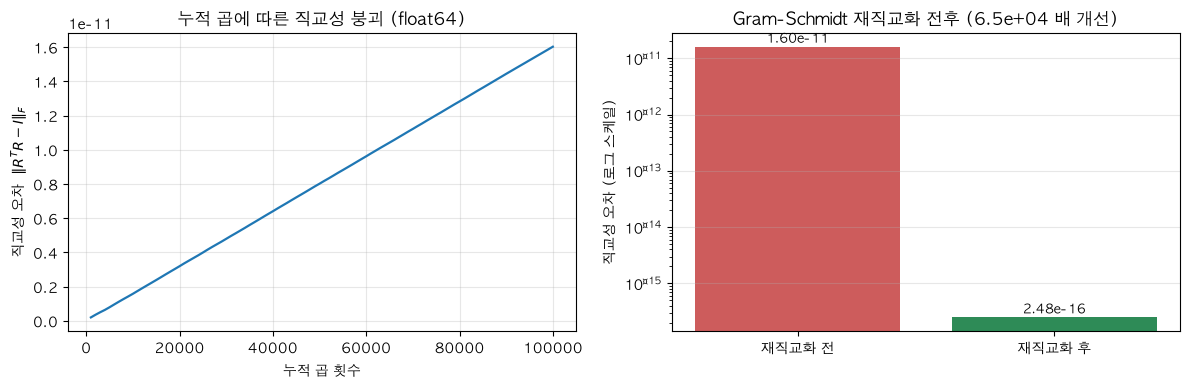

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_n, history_err, lw=1.6)
axes[0].set_xlabel("누적 곱 횟수")
axes[0].set_ylabel(r"직교성 오차  $\|R^T R - I\|_F$")
axes[0].set_title("누적 곱에 따른 직교성 붕괴 (float64)")
axes[0].grid(alpha=0.3)

labels = ["재직교화 전", "재직교화 후"]
vals = [err_before, max(err_after, 1e-18)]
bars = axes[1].bar(labels, vals, color=["indianred", "seagreen"])
axes[1].set_yscale("log")
axes[1].set_ylabel("직교성 오차 (로그 스케일)")
axes[1].set_title("Gram-Schmidt 재직교화 전후 ({:.1e} 배 개선)".format(improvement))
for bar, v in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v, "{:.2e}".format(v),
                 ha="center", va="bottom", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [20]:
# --- 검증 ---
ok = check("재직교화 후 오차가 전보다 작다", err_after < err_before)
ok &= check("재직교화 후 오차가 기계정밀도 수준 (< 1e-14)", err_after < 1e-14)
ok &= check("복구 행렬의 행렬식이 1", np.isclose(det_after, 1.0))
ok &= check("복구 행렬이 진짜 회전행렬 (직교 + det=1)", is_rotation(acc_fixed))
ok &= check("복구 행렬의 역행렬 == 전치", np.allclose(np.linalg.inv(acc_fixed), acc_fixed.T))
ok &= check("자세가 크게 바뀌지 않았다 (차이 < 1e-6)", np.max(np.abs(acc_fixed - acc)) < 1e-6)
ok &= check("이미 직교인 행렬에 적용해도 그대로",
            np.allclose(gram_schmidt(rot_z(0.4)), rot_z(0.4)))
print("\n3-2 전체 통과:", ok)

[PASS] 재직교화 후 오차가 전보다 작다
[PASS] 재직교화 후 오차가 기계정밀도 수준 (< 1e-14)
[PASS] 복구 행렬의 행렬식이 1
[PASS] 복구 행렬이 진짜 회전행렬 (직교 + det=1)
[PASS] 복구 행렬의 역행렬 == 전치
[PASS] 자세가 크게 바뀌지 않았다 (차이 < 1e-6)
[PASS] 이미 직교인 행렬에 적용해도 그대로

3-2 전체 통과: True


## 3-3. `tests/test_rotation.py` — pytest 4가지 검증

지시문이 요구한 네 가지를 각각 테스트 함수로 만들었습니다.

| # | 테스트 | 함수 |
|---|---|---|
| ① | 회전행렬의 열이 서로 직교하는 단위벡터인가 | `test_columns_are_orthonormal` |
| ② | 행렬식이 1인가 | `test_determinant_is_one` |
| ③ | 역행렬이 전치와 같은가 | `test_inverse_equals_transpose` |
| ④ | 재직교화 결과가 직교행렬인가 | `test_gram_schmidt_restores_orthogonality` |

여기에 반사 행렬 반례, 누적 오차 복구, 로드리게스 일치, 축·각 왕복까지 더했습니다.
`@pytest.mark.parametrize` 로 세 축 x 일곱 각도를 조합해 한 함수가 21 케이스를 검사합니다.

In [21]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_rotation.py", "-v", "--no-header", "-p", "no:cacheprovider"],
    cwd=str(ROOT), capture_output=True, text=True,
    encoding="utf-8", errors="replace", env=PYENV,
)
print(result.stdout[-6000:])
print("종료 코드 :", result.returncode)

rot_y] PASSED [ 12%]
tests/test_rotation.py::test_columns_are_orthonormal[0.7853981633974483-rot_z] PASSED [ 14%]
tests/test_rotation.py::test_columns_are_orthonormal[1.5707963267948966-rot_x] PASSED [ 15%]
tests/test_rotation.py::test_columns_are_orthonormal[1.5707963267948966-rot_y] PASSED [ 17%]
tests/test_rotation.py::test_columns_are_orthonormal[1.5707963267948966-rot_z] PASSED [ 18%]
tests/test_rotation.py::test_columns_are_orthonormal[2.0-rot_x] PASSED   [ 20%]
tests/test_rotation.py::test_columns_are_orthonormal[2.0-rot_y] PASSED   [ 21%]
tests/test_rotation.py::test_columns_are_orthonormal[2.0-rot_z] PASSED   [ 23%]
tests/test_rotation.py::test_columns_are_orthonormal[3.141592653589793-rot_x] PASSED [ 25%]
tests/test_rotation.py::test_columns_are_orthonormal[3.141592653589793-rot_y] PASSED [ 26%]
tests/test_rotation.py::test_columns_are_orthonormal[3.141592653589793-rot_z] PASSED [ 28%]
tests/test_rotation.py::test_columns_are_orthonormal[-1.234-rot_x] PASSED [ 29%]
tests/test

In [22]:
# --- 검증 ---
ok = check("pytest 전수 통과 (종료 코드 0)", result.returncode == 0)
ok &= check("실패/에러가 없다", ("failed" not in result.stdout) and ("error" not in result.stdout.lower()))
ok &= check("요구된 4가지 테스트가 모두 존재", all(
    name in result.stdout for name in [
        "test_columns_are_orthonormal",
        "test_determinant_is_one",
        "test_inverse_equals_transpose",
        "test_gram_schmidt_restores_orthogonality",
    ]))
print("\n3-3 전체 통과:", ok)

[PASS] pytest 전수 통과 (종료 코드 0)
[PASS] 실패/에러가 없다
[PASS] 요구된 4가지 테스트가 모두 존재

3-3 전체 통과: True


## 3-4. 일부러 틀리게 바꿔 보기 — 테스트가 잡아내는가

테스트가 "항상 통과하는 테스트" 가 아니라는 것을 보이려면
**일부러 버그를 넣어 실패하는지** 확인해야 합니다(뮤테이션 테스트의 축소판).

`rot_z` 의 첫 행 부호를 뒤집어 $\begin{bmatrix}c&s&0\\s&c&0\\0&0&1\end{bmatrix}$ 로 만듭니다.
이 행렬은 대칭이라 열이 직교하지 않고($2cs \neq 0$), 행렬식도
$c^2-s^2=\cos 2\theta \neq 1$ 입니다. ①②③ 이 모두 깨져야 정상입니다.

아래 셀은 소스를 임시로 고친 뒤 **`finally` 에서 반드시 원본으로 되돌립니다.**

In [24]:
src_path = ROOT / "src" / "rotation.py"
original = src_path.read_text(encoding="utf-8")

BUG_FROM = "return np.array([[c, -s, 0.0],"
BUG_TO = "return np.array([[c, s, 0.0],   # <-- 일부러 넣은 버그 (부호 뒤집음)"
assert original.count(BUG_FROM) == 1, "치환 대상이 rot_z 한 곳이어야 합니다"

try:
    src_path.write_text(original.replace(BUG_FROM, BUG_TO), encoding="utf-8")
    broken = subprocess.run(
        [sys.executable, "-m", "pytest", "tests/test_rotation.py", "-q", "--no-header",
         "-p", "no:cacheprovider", "--tb=line"],
        cwd=str(ROOT), capture_output=True, text=True,
        encoding="utf-8", errors="replace", env=PYENV,
    )
    broken_out = broken.stdout
    broken_code = broken.returncode
finally:
    src_path.write_text(original, encoding="utf-8")     # 반드시 원상복구
print(broken_out[-5000:])
print("종료 코드 :", broken_code, " (0 이 아니어야 정상 — 테스트가 버그를 잡았다는 뜻)")

ation.py:57: AssertionError: assert False
E   AssertionError: assert False
     +  where False = <function allclose at 0x10d272cb0>(array([[0.63665708, 1.39112109, 0.        ],\n       [1.39112109, 0.63665708, 0.        ],\n       [0.        , 0.        , 1.        ]]), array([[-0.41614684,  0.90929743,  0.        ],\n       [ 0.90929743, -0.41614684,  0.        ],\n       [ 0.        ,  0.        ,  1.        ]]))
     +    where <function allclose at 0x10d272cb0> = np.allclose
     +    and   array([[0.63665708, 1.39112109, 0.        ],\n       [1.39112109, 0.63665708, 0.        ],\n       [0.        , 0.        , 1.        ]]) = <function inv at 0x10d415230>(array([[-0.41614684,  0.90929743,  0.        ],\n       [ 0.90929743, -0.41614684,  0.        ],\n       [ 0.        ,  0.        ,  1.        ]]))
     +      where <function inv at 0x10d415230> = <module 'numpy.linalg' from '/Users/user/lv1_module3/.venv/lib/python3.14/site-packages/numpy/linalg/__init__.py'>.inv
     +       

In [25]:
# 원상복구 확인 후 다시 전수 통과하는지
restored = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "--no-header", "-p", "no:cacheprovider"],
    cwd=str(ROOT), capture_output=True, text=True,
    encoding="utf-8", errors="replace", env=PYENV,
)
print(restored.stdout[-1500:])
print("복구 후 종료 코드 :", restored.returncode)

................................................................         [100%]
64 passed in 0.20s

복구 후 종료 코드 : 0


In [26]:
# --- 검증 ---
ok = check("버그를 넣으면 테스트가 실패한다", broken_code != 0)
ok &= check("실패 목록에 '열 직교성' 테스트가 있다", "test_columns_are_orthonormal" in broken_out)
ok &= check("실패 목록에 '행렬식' 테스트가 있다", "test_determinant_is_one" in broken_out)
ok &= check("실패 목록에 '역행렬 == 전치' 테스트가 있다", "test_inverse_equals_transpose" in broken_out)
ok &= check("소스가 원본으로 복구되었다", src_path.read_text(encoding="utf-8") == original)
ok &= check("복구 후 전체 테스트 재통과", restored.returncode == 0)
print("\n3-4 전체 통과:", ok)

[PASS] 버그를 넣으면 테스트가 실패한다
[PASS] 실패 목록에 '열 직교성' 테스트가 있다
[PASS] 실패 목록에 '행렬식' 테스트가 있다
[PASS] 실패 목록에 '역행렬 == 전치' 테스트가 있다
[PASS] 소스가 원본으로 복구되었다
[PASS] 복구 후 전체 테스트 재통과

3-4 전체 통과: True


## 답안 템플릿 정리

In [27]:
summary = """
1. 10만 번 누적 후 직교성 오차: {before:.6e}   (지표: ||R^T R - I||_F)
   - 같은 실험을 float32 로 하면 {e32:.3e} 로 약 {ratio:.0f} 배 커진다 (정밀도의 영향)

2. 재직교화 후 오차: {after:.6e}  -> 개선 배율: {imp:.3e} 배
   - 자세 자체는 최대 {delta:.2e} 밖에 안 바뀌므로, 회전을 유지한 채 직교성만 되돌린 것

3. 복구 행렬의 행렬식: {det_after:.15f}  (직교 + det=1 이므로 진짜 회전행렬)

4. pytest -v 전수 통과 출력: 위 3-3 셀 참조 — 종료 코드 {rc}, 총 {ntest} 개 케이스 통과

5. 함수를 틀리게 바꿨을 때 실패 출력: 위 3-4 셀 참조 — 종료 코드 {bc},
   열 직교성 / 행렬식 / 역행렬=전치 테스트가 모두 실패로 잡힘. finally 로 원본 복구 완료.
""".format(
    before=err_before, e32=err32, ratio=err32 / err_before,
    after=err_after, imp=improvement,
    delta=float(np.max(np.abs(acc_fixed - acc))),
    det_after=det_after,
    rc=result.returncode,
    ntest=result.stdout.count("PASSED"),
    bc=broken_code,
)
print(summary)


1. 10만 번 누적 후 직교성 오차: 1.602948e-11   (지표: ||R^T R - I||_F)
   - 같은 실험을 float32 로 하면 2.171e-03 로 약 135468855 배 커진다 (정밀도의 영향)

2. 재직교화 후 오차: 2.483275e-16  -> 개선 배율: 6.455e+04 배
   - 자세 자체는 최대 5.18e-12 밖에 안 바뀌므로, 회전을 유지한 채 직교성만 되돌린 것

3. 복구 행렬의 행렬식: 1.000000000000000  (직교 + det=1 이므로 진짜 회전행렬)

4. pytest -v 전수 통과 출력: 위 3-3 셀 참조 — 종료 코드 0, 총 64 개 케이스 통과

5. 함수를 틀리게 바꿨을 때 실패 출력: 위 3-4 셀 참조 — 종료 코드 1,
   열 직교성 / 행렬식 / 역행렬=전치 테스트가 모두 실패로 잡힘. finally 로 원본 복구 완료.

